<a href="https://colab.research.google.com/github/priyalpatil31/AML_Priyal_Patil_19/blob/main/EXP_4%2C5%2C7%2C8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
PCA Reduced Features
          0         1
0  0.879264  2.117707
1 -1.731009 -0.031643
2 -0.716871 -0.337108
3  0.879797  2.116523
4  0.879930  2.116227

LDA Reduced Features
          0
0 -1.140732
1  1.589544
2  1.119627
3 -1.139040
4 -1.138617

PCA Accuracy : 0.6818181818181818

LDA Accuracy : 0.7467532467532467


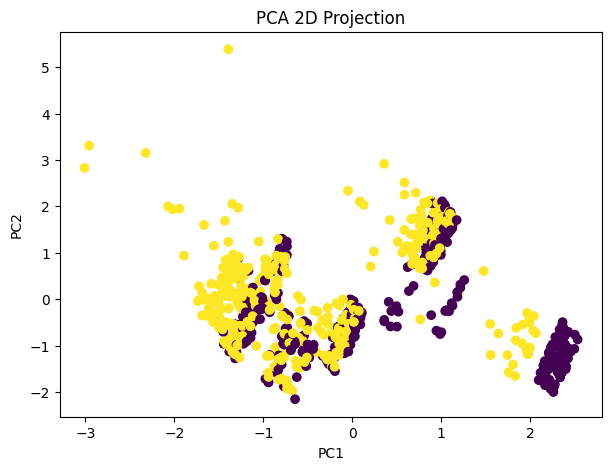

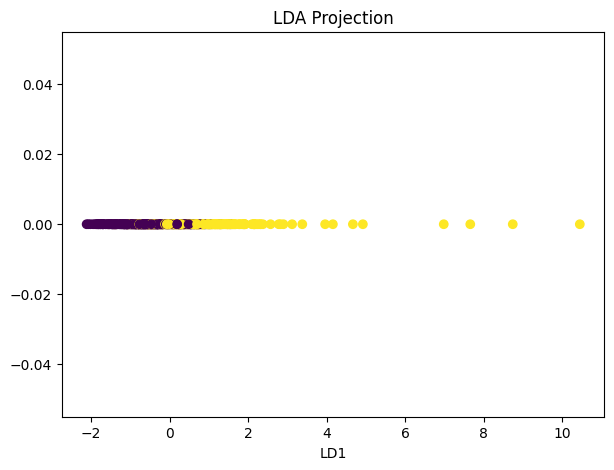


COMMENT
PCA focuses on maximum variance.
LDA focuses on maximum class separation.
LDA usually gives better classification accuracy.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

path = "/content/drive/MyDrive/Online_Retail_Small.xlsx"

df = pd.read_excel(path)

df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype(str)

for col in df.columns:
    if "date" in col.lower():
        df.drop(col, axis=1, inplace=True)

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df['Target'] = pd.qcut(df['Quantity'], q=2, labels=[0,1])

X = df.drop('Target', axis=1)
y = df['Target']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA Reduced Features")
print(pd.DataFrame(X_pca).head())

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

print("\nLDA Reduced Features")
print(pd.DataFrame(X_lda).head())

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model1 = LogisticRegression()

model1.fit(X_train_pca, y_train)

pred1 = model1.predict(X_test_pca)

acc1 = accuracy_score(y_test, pred1)

print("\nPCA Accuracy :", acc1)

X_train_lda, X_test_lda, y_train, y_test = train_test_split(
    X_lda, y, test_size=0.2, random_state=42
)

model2 = LogisticRegression()

model2.fit(X_train_lda, y_train)

pred2 = model2.predict(X_test_lda)

acc2 = accuracy_score(y_test, pred2)

print("\nLDA Accuracy :", acc2)

plt.figure(figsize=(7,5))

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

plt.title("PCA 2D Projection")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

plt.figure(figsize=(7,5))

plt.scatter(X_lda[:,0], [0]*len(X_lda), c=y)

plt.title("LDA Projection")

plt.xlabel("LD1")

plt.show()

print("\nCOMMENT")
print("PCA focuses on maximum variance.")
print("LDA focuses on maximum class separation.")
print("LDA usually gives better classification accuracy.")

In [4]:
# =========================================
# EXPERIMENT 5
# Pune House Price Prediction Using ML
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

path = "/content/drive/MyDrive/Housing.csv"

df = pd.read_csv(path)

print("FIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns)

print("\nMISSING VALUES")
print(df.isnull().sum())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df = df.fillna(df.mean(numeric_only=True))

numeric_df = df.select_dtypes(include=['int64','float64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((numeric_df < (Q1 - 1.5 * IQR)) |
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

target = df.columns[-1]

X = df.drop(target, axis=1)
y = df[target]

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("\n", name)

    print("MAE :", mean_absolute_error(y_test, pred))

    print("MSE :", mean_squared_error(y_test, pred))

    print("R2 Score :", r2_score(y_test, pred))

best_model = RandomForestRegressor()

best_model.fit(X_train, y_train)

importance = pd.Series(
    best_model.feature_importances_,
    index=df.drop(target, axis=1).columns
)

print("\nFEATURE IMPORTANCE")
print(importance.sort_values(ascending=False))

print("\nBEST MODEL : RANDOM FOREST REGRESSOR")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FIRST 5 ROWS
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no           

In [7]:
# =========================================
# EXPERIMENT 7
# Develop SVM Model
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

path = "/content/drive/MyDrive/bc7a6e63-9658-4390-aa02-30da1243c761.csv"

df = pd.read_csv(path)

df = df.dropna(axis=1, how='all')

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df = df.fillna(0)

target = "loan_status"

X = df.drop(target, axis=1)
y = df[target]

if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Kernel": SVC(kernel='linear'),
    "RBF Kernel": SVC(kernel='rbf'),
    "Polynomial Kernel": SVC(kernel='poly')
}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("\n====================")
    print(name)
    print("====================")

    print("Confusion Matrix")
    print(confusion_matrix(y_test, pred))

    print("Accuracy :", accuracy_score(y_test, pred))

    print("Precision :", precision_score(y_test, pred, average='weighted'))

    print("Recall :", recall_score(y_test, pred, average='weighted'))

    print("F1 Score :", f1_score(y_test, pred, average='weighted'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_2200/2515568704.py:23: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)



Linear Kernel
Confusion Matrix
[[1078    0   16]
 [   0  262    0]
 [   0    0 6588]]
Accuracy : 0.9979859013091642
Precision : 0.9979907810152594
Recall : 0.9979859013091642
F1 Score : 0.9979797043038993

RBF Kernel
Confusion Matrix
[[ 960    0  134]
 [   0  262    0]
 [   0    0 6588]]
Accuracy : 0.9831319234642497
Precision : 0.9834681808661823
Recall : 0.9831319234642497
F1 Score : 0.9826666096401456

Polynomial Kernel
Confusion Matrix
[[ 852    0  242]
 [   0  262    0]
 [   5    0 6583]]
Accuracy : 0.9689073514602216
Precision : 0.969791136207004
Recall : 0.9689073514602216
F1 Score : 0.967293538205036


In [11]:
# =========================================
# EXPERIMENT 8
# Bank Marketing Prediction
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

path = "/content/drive/MyDrive/loan.csv"

df = pd.read_csv(path)

print(df.head())

print("\nCOLUMN NAMES")
print(df.columns)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df = df.fillna(0)

target = df.columns[-1]

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, pred))

print("\nACCURACY")
print(accuracy_score(y_test, pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, pred))

print("\nMODEL USED : LOGISTIC REGRESSION")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_2200/533662272.py:19: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  1077501    1296599       5000         5000           4975.0   36 months   
1  1077430    1314167       2500         2500           2500.0   60 months   
2  1077175    1313524       2400         2400           2400.0   36 months   
3  1076863    1277178      10000        10000          10000.0   36 months   
4  1075358    1311748       3000         3000           3000.0   60 months   

  int_rate  installment grade sub_grade  ... num_tl_90g_dpd_24m  \
0   10.65%       162.87     B        B2  ...                NaN   
1   15.27%        59.83     C        C4  ...                NaN   
2   15.96%        84.33     C        C5  ...                NaN   
3   13.49%       339.31     C        C1  ...                NaN   
4   12.69%        67.79     B        B5  ...                NaN   

  num_tl_op_past_12m pct_tl_nvr_dlq  percent_bc_gt_75 pub_rec_bankruptcies  \
0                NaN            NaN               

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.float64(0.0)